<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week9/DATA_201_Week_9A_Over_Under_Fit_Demo_and_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 Underfitting, Good Fit, and Overfitting with Linear Regression

This notebook gives one integrated classroom example on:

- **underfitting**
- a **reasonable fit**
- **overfitting**

It also shows where **train/test split** and **cross-validation** fit into the workflow.



## Learning goals

By the end of this notebook, students should be able to:

1. explain the difference between **training error** and **test error**
2. identify **underfitting** and **overfitting** from plots and model results
3. explain why a **train/test split** is needed
4. describe how **cross-validation** helps choose model complexity

---

## The setup

Suppose we want to predict a student's exam score from hours studied.

In real life, relationships are often **not perfectly linear**. To make the ideas visible, we will simulate data from a curved relationship with some random noise.

Then we will compare polynomial regression models of different complexity:

- degree 1: too simple, likely **underfits**
- degree 3: usually a reasonable compromise
- degree 12: very flexible, likely **overfits**

Although we are using polynomial features, the final model is still a form of **linear regression** because it is linear in the coefficients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

## Generate a dataset

We create one predictor:

- `hours_studied`

and one response:

- `exam_score`

The true relationship is curved, not exactly a straight line. We also add random noise, because real data are never perfectly clean.

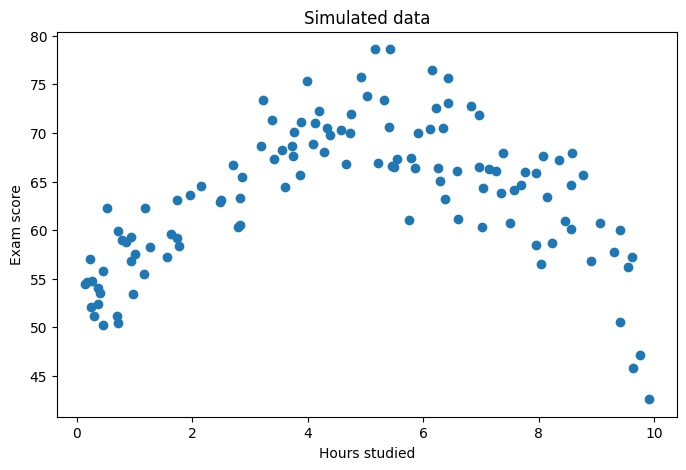

In [3]:
# Simulated study hours
n = 120
X = np.random.uniform(0, 10, size=n)
X = np.sort(X)

# True curved relationship + noise
true_y = 50 + 8*X - 0.8*(X**2)
noise = np.random.normal(0, 4, size=n)
y = true_y + noise

X = X.reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Simulated data")
plt.show()

## Why split into training and test sets?

A model can always look better on the data it has already seen.

So we split the dataset into:

- a **training set** to fit the model
- a **test set** to evaluate how well the model works on new data

This helps us measure **generalization** rather than memorization.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=7
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 84
Test observations: 36


## Build three models

We will fit three polynomial regression models:

1. **degree 1**: straight line
2. **degree 3**: moderate flexibility
3. **degree 12**: very flexible

For each model, we will compare:

- training RMSE
- test RMSE

Recall: lower RMSE means better predictions.

In [5]:
def make_model(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr", LinearRegression())
    ])

models = {
    "Degree 1": make_model(1),
    "Degree 3": make_model(3),
    "Degree 12": make_model(12),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append((name, train_rmse, test_rmse, train_r2, test_r2))

for row in results:
    print(f"{row[0]:10s} | train RMSE = {row[1]:6.2f} | test RMSE = {row[2]:6.2f} | train R^2 = {row[3]:5.3f} | test R^2 = {row[4]:5.3f}")

Degree 1   | train RMSE =   6.66 | test RMSE =   8.02 | train R^2 = 0.037 | test R^2 = -0.025
Degree 3   | train RMSE =   3.31 | test RMSE =   4.80 | train R^2 = 0.762 | test R^2 = 0.632
Degree 12  | train RMSE =   2.93 | test RMSE =   4.77 | train R^2 = 0.814 | test R^2 = 0.638


## Plot the fitted curves

The next plot lets students see how model complexity affects the fit.

Look for these patterns:

- **Degree 1**: too rigid to follow the curved pattern
- **Degree 3**: captures the main structure without too much wiggle
- **Degree 12**: may chase noise in the training data

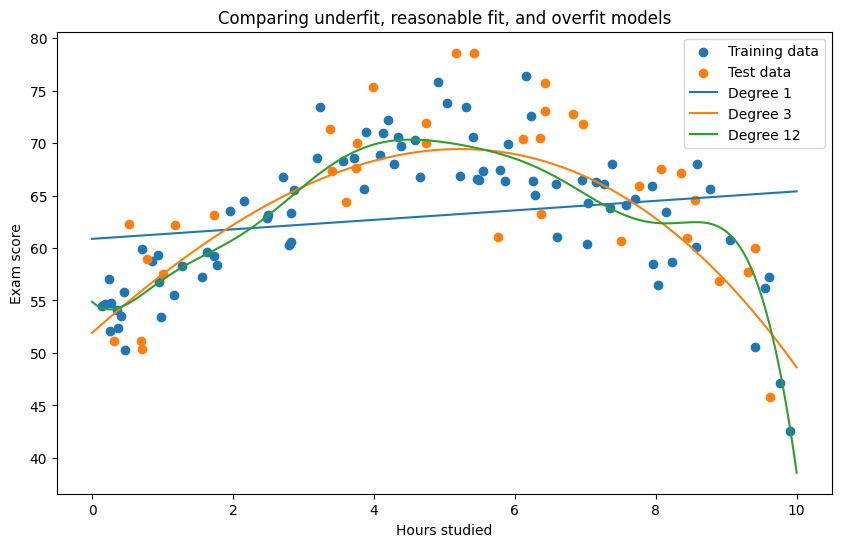

In [11]:
fig_x = np.linspace(0, 10, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, label="Test data")

for name, model in models.items():
    model.fit(X_train, y_train)
    plt.plot(fig_x, model.predict(fig_x), label=name)

plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.title("Comparing underfit, reasonable fit, and overfit models")
plt.legend()
plt.show()

#change 1 to 4, 3 to 6, 12 to 20

## Interpreting the three models

### 1. Degree 1: Underfitting

This model is too simple. It tries to force a straight line through a curved relationship.

Typical signs:

- training error is fairly high
- test error is also high
- the model misses an obvious pattern visible in the plot

### 2. Degree 3: Better balance

This model is flexible enough to capture the main pattern, but not so flexible that it bends around every random fluctuation.

Typical signs:

- training error is lower than degree 1
- test error is also reasonably low
- the fitted curve follows the overall shape of the data

### 3. Degree 12: Overfitting

This model is very flexible. It can fit noise in the training data, not just the underlying pattern.

Typical signs:

- training error may become very small
- test error can increase
- the curve may wiggle in unrealistic ways

The important lesson is this:

> A model that looks best on the training data is not always the model that predicts best on new data.

## Cross-validation: where it fits

A train/test split gives one estimate of performance on new data.

But one split can be lucky or unlucky.

**Cross-validation** improves this by repeatedly dividing the training data into smaller training and validation parts. This gives a more stable estimate of how well each model generalizes.

A common workflow is:

1. split data into **training** and **test** sets
2. use **cross-validation on the training set** to choose model complexity
3. evaluate the chosen model one final time on the **test set**

So:

- **test set** = final exam
- **cross-validation** = practice exams

In [7]:
degrees = list(range(1, 13))
cv_rmse = []

for d in degrees:
    model = make_model(d)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    cv_rmse.append(-scores.mean())

best_degree = degrees[int(np.argmin(cv_rmse))]
print("Best degree by 5-fold CV:", best_degree)

Best degree by 5-fold CV: 6


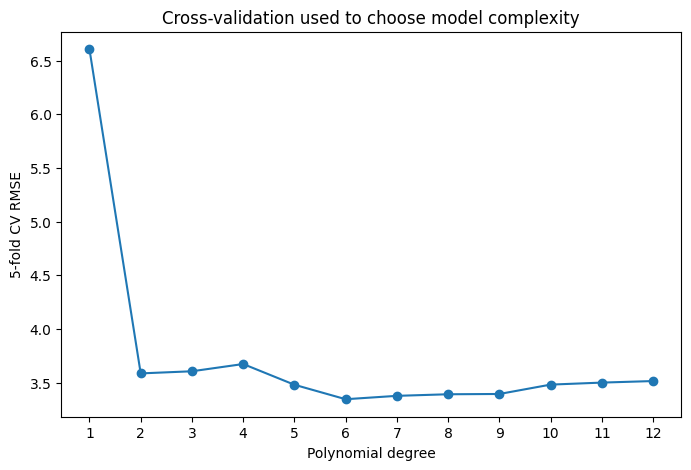

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, cv_rmse, marker="o")
plt.xlabel("Polynomial degree")
plt.ylabel("5-fold CV RMSE")
plt.title("Cross-validation used to choose model complexity")
plt.xticks(degrees)
plt.show()

## Fit the model chosen by cross-validation

Now we fit the model selected by cross-validation to the full training set and then evaluate it on the test set.

This mirrors a standard machine learning workflow.

In [10]:
best_model = make_model(best_degree)
best_model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("Chosen degree:", best_degree)
print("Training RMSE:", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
print("Test RMSE:    ", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2))

Chosen degree: 6
Training RMSE: 2.97
Test RMSE:     4.79


## Connecting this to statistical learning versus machine learning

This example uses the same basic tool, **linear regression**, in two different ways.

### Statistical learning view

If the goal is to understand the relationship between study hours and exam scores, we might:

- fit a regression model to all available data
- interpret the coefficients
- ask whether the relationship appears linear or curved
- focus on explanation and inference

### Machine learning view

If the goal is prediction, we instead ask:

- which model predicts new students' exam scores best?
- how do we measure performance on unseen data?

That is why train/test split and cross-validation become central.

In other words:

- **statistical learning** often emphasizes interpretation
- **machine learning** emphasizes out-of-sample prediction

## Active learning exercise

This activity can be done individually or in small groups.

### Part A: Predict before running code

Before re-running any cells, look at the plot of the data and answer:

1. Which model do you think will **underfit**?
2. Which model do you think will **overfit**?
3. Which model do you think will have the **lowest test RMSE**?
4. Why is the model with the smallest training error not automatically the best model?

Write down your answers before checking the results.

### Part B: Interpret the output

After running the notebook, discuss:

1. Which model had the lowest **training** RMSE?
2. Which model had the lowest **test** RMSE?
3. Did the same model win on both?
4. Which model shows the clearest evidence of overfitting?
5. Which model shows the clearest evidence of underfitting?

### Part C: Modify the notebook

Change one of the following and predict what will happen before running the code:

- increase the noise level
- reduce the sample size from 120 to 40
- test polynomial degrees up to 20 instead of 12
- change the random seed

Then answer:

1. Did overfitting become easier or harder to see?
2. Did the best degree chosen by cross-validation change?
3. Was the test error estimate stable, or did it vary a lot?

### Part D: Extension question

Suppose a classmate says:

> "The degree 12 model must be best because it fits the training data most closely."

Write a 2-3 sentence response explaining why this reasoning is incomplete.